# Compact
Load Compact CSV files and create a DataFrame named `df`.

In [53]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Compact"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
df_clean = df.copy()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df_clean.head()

Loaded 2045 rows from 214 file(s) in /Users/gretawette/Documents/Thesis/data/raw/Alternative Medien/Compact


,Date,Title,Inhalt,URL,source,source_file
0,2025-06-11,COMPACT gegen Regierung: So war der 2. Tag!,Der zweite und letzte Verhandlungstag im COMPACT-Verbotsverfahren ist abgeschlossen. Das Urteil wird am 24.06. bekannt gegeben. Wie verlief es heute vor Gericht? Wessen Chancen stehen am Ende besser? Kann sich die Regierung durchsetzen oder obsiegt die Pressefreiheit? Eine Analyse und die Prognose zu diesem historischen Verfahren liefern Ihnen das Ehepaar Elsässer und Paul Klemm.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,https://www.compact-online.de/compact-gegen-regierung-so-war-der-2-tag/,Compact,Compact_2025-06-11_raw.csv
1,2025-06-11,COMPACT-Verbot 2024: Der Film,"Als Nancy Faeser eskalierte. Die denkwürdigsten Szenen des 16. Juli 2024, also plötzlich die Formate von COMPACT verboten wurden.\n\nUnser Cutter hat anlässlich des laufenden Verbotsverfahren die bemerkenswertesten Szenen zusammengeschnitten.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/compact-verbot-2024-der-film/,Compact,Compact_2025-06-11_raw.csv
2,2025-06-11,Drogen und Rituale: Mysteriöse Inka-Stätte entdeckt,"Ein neuer Fund in den peruanischen Anden eröffnet einen neuen Blick auf die Kultur der Inka: Sie waren nicht nur große Baumeister, sondern erforschten auch astronomische und spirituelle Geheimnisse – unter Einsatz psychoaktiver Substanzen. Mehr über die Frühzeit der Menschheit und historische Ungereimtheiten lesen Sie „Geheime Geschichte – Von den Pharaonen bis zur Kabale im Vatikan“ – unserer neuen Geschichtsausgabe. Hier mehr erfahren. \n\nHoch oben in den schroffen Felsen der peruanischen Anden, auf fast 3.000 Metern Höhe, haben Archäologen eine Entdeckung gemacht, die nicht nur die Fachwelt elektrisiert: Ein geheimer, unterirdischer Raum, der vermutlich seit Jahrtausenden unberührt war, gibt nun Einblicke in die mysteriösen Rituale der Inka – jenes alten lateinamerikanischen Volkes, das um die Hauptstadt Cusco im heutigen Peru lebte und ab 1438 viele Gebiete eroberte, insbesondere im Anden-Gebirge. Das Reich der Inka gilt als das größte seiner Zeit und umfasste schätzungsweise ...",https://www.compact-online.de/drogen-und-rituale-mysterioese-inka-staette-entdeckt/,Compact,Compact_2025-06-11_raw.csv
3,2025-06-11,Trumps Einsatz in Los Angeles: Ein Medientrauma,"Das Durchgreifen des US-Präsidenten gegen das Treiben illegaler Einwanderer in Los Angeles treibt etablierte Medien um. Wir zeigen auf, wie Trump tickt und was wir von ihm noch zu erwarten haben. Sichern Sie sich am besten gleich unsere Sonderausgabe „Trump. Sein Leben. Seine Politik. Sein großes Comeback.“ Hier mehr erfahren.\n\nDie Straßen von Los Angeles stehen in Flammen – brennende Polizeiwagen, fliegende Steine und Proteste. Die Szenen lassen an einen Bürgerkrieg denken. Auslöser der Krawalle waren Razzien der Einwanderungsbehörden gegen illegale Migranten. Präsident Donald Trump reagiert entschlossen und schickt 2.000 Soldaten der Nationalgarde sowie 700 Marines, um die Gewalt in den Griff zu bekommen – ein Schritt, der weltweit für Schlagzeilen sorgt. Die internationale Presse ist in Aufruhr, die Meinungen aus der Straße sind gespalten.\n\nTrumps Entscheidung, Kaliforniens Gouverneur Gavin Newsom und die Bürgermeisterin von Los Angeles, Karen Bass, beide Demokraten, zu über...",https://www.compact-online.de/trumps-einsatz-in-los-angeles-ein-medientrauma/,Compact,Compact_2025-06-11_raw.csv
4,2025-06-11,Verrat an BismarckCOMPACT+,"Essay von Rolf Hochhut. Deutschland hat seinen großen Kanzler vergessen – vor allem von seiner klugen Ausgleichspolitik mit Russland wollen die heutigen NATO-Vasallen nichts mehr wissen. _ von Rolf Hochhuth Bismarcks geheimer Rückversicherungsvertrag mit Russland sah vor: Berlin und Petersburg bleiben «wohlwollend neutral», wird eines der beiden Länder «in Krieg mit einer Großmacht verwicke

In [41]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
Date,0,0.0
Title,0,0.0
Inhalt,0,0.0
URL,0,0.0
source,0,0.0
source_file,0,0.0


In [42]:
# filter timeframe Aug 2025 through Jan 2026 (inclusive) and keep as df_clean
start, end = "2025-08-01", "2026-01-31"

dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

df_clean = df_clean.loc[mask].copy()
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()

Rows in selected period: 1614


,Date,Title,Inhalt,URL,source,source_file
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/,Compact,Compact_2025-08-01_raw.csv
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/,Compact,Compact_2025-08-01_raw.csv
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/,Compact,Compact_2025-08-01_raw.csv
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/,Compact,Compact_2025-08-01_raw.csv
348,2025-08-01

Date filter

In [43]:
df_clean['Date'].min(), df_clean['Date'].max()

(Timestamp('2025-08-01 00:00:00'), Timestamp('2026-01-31 00:00:00'))

In [44]:
# keep only the requested columns
_keep = ["Date", "Title", "Inhalt", "URL"]

if 'df_clean' in globals():
    df_clean = df_clean.loc[:, _keep].copy()

if 'df_aug2025_jan2026' in globals():
    df_aug2025_jan2026 = df_aug2025_jan2026.loc[:, _keep].copy()

if 'df' in globals():
    df = df.loc[:, _keep].copy()

# show result
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nich

In [45]:
from IPython.display import display
display(df_clean.head(3))

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/


Removal of "Mehr zum Thema"

In [46]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Inhalt"] = df_clean["Inhalt"].apply(remove_mehr_zum_thema)

In [47]:
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nich

In [48]:
# rename column "Inhalt" to "Text"
if "Inhalt" in df_clean.columns:
    df_clean = df_clean.rename(columns={"Inhalt": "Text"})

df_clean.head()

,Date,Title,Text,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nicht.

Duplicates

In [49]:
# Columns to check for duplicate records
dup_cols = ["Title"]

# Find duplicates (all rows that belong to duplicate groups)
dup_mask = df_clean.duplicated(subset=dup_cols, keep=False)
dups = df_clean.loc[dup_mask].sort_values(dup_cols)

print(f"Number of duplicate rows (across {dup_cols}): {len(dups)}")

# optional preview
dups.head()

Number of duplicate rows (across ['Title']): 75


,Date,Title,Text,URL
1015,2025-10-20,15 Jahre COMPACT: Die Jubiläums-Gala,"Am 31. Januar 2026 feiern wir in Magdeburg den 15. Geburtstag unseres Magazins – mit prominenten Rednern wie Diether Dehm, Markus Krall, Björn Höcke und Kavan Soufi-Siavash. Jetzt anmelden: am Ende dieses Artikels.\n\nWahnsinn: Im Dezember ist es 15 Jahre her, dass COMPACT aus der Taufe gehoben wurde. Das wollen wir mit Ihnen auf einer großen Gala feiern, und zwar am 31. Januar 2026 in Magdeburg! Als Redner stehen bereits fest:\n\nDer Thüringer AfD-Landeschef Björn Höcke.\nStar-Ökonom Dr. Markus Krall.\nDas linke Polit-Schlachtross Dr. Diether Dehm\nder berühmte Friedens-Aktivist Kayvan Soufi-Siavash (Ken Jebsen)\nFür den festlichen Rahmen sorgt unter anderem eine Konzert-Pianistin!\nFür die Zukunft der Familie! Jürgen Elsässerund Thilo Sarrazin\nauf der COMPACT-Konferenz im Jahr 2013. Foto: Gründler\n\nIch selbst werde einen Rückblick auf 15 Jahren COMPACT-Geschichte geben, und dazu wird es in Erstaufführung auch unseren neuer Film geben: „15 Jahre Mut zur Wahrheit“. Natürlich g...",https://www.compact-online.de/15-jahre-compact-die-jubilaeums-gala/
1114,2025-10-29,15 Jahre COMPACT: Die Jubiläums-Gala,"Am 31. Januar 2026 feiern wir in Magdeburg den 15. Geburtstag unseres Magazins – mit prominenten Rednern wie Diether Dehm, Markus Krall, Björn Höcke und Kavan Soufi-Siavash. Jetzt anmelden: am Ende dieses Artikels.\n\nWahnsinn: Im Dezember ist es 15 Jahre her, dass COMPACT aus der Taufe gehoben wurde. Das wollen wir mit Ihnen auf einer großen Gala feiern, und zwar am 31. Januar 2026 in Magdeburg! Als Redner stehen bereits fest:\n\nDer Thüringer AfD-Landeschef Björn Höcke.\nStar-Ökonom Dr. Markus Krall.\nDas linke Polit-Schlachtross Dr. Diether Dehm\nder berühmte Friedens-Aktivist Kayvan Soufi-Siavash (Ken Jebsen)\nFür den festlichen Rahmen sorgt unter anderem eine Konzert-Pianistin!\nFür die Zukunft der Familie! Jürgen Elsässerund Thilo Sarrazin\nauf der COMPACT-Konferenz im Jahr 2013. Foto: Gründler\n\nIch selbst werde einen Rückblick auf 15 Jahren COMPACT-Geschichte geben, und dazu wird es in Erstaufführung auch unseren neuer Film geben: „15 Jahre Mut zur Wahrheit“. Natürlich g...",https://www.compact-online.de/15-jahre-compact-die-jubilaeums-gala/
1193,2025-11-09,15 Jahre COMPACT: Die Jubiläums-Gala,"Am 31. Januar 2026 feiern wir in Magdeburg den 15. Geburtstag unseres Magazins – mit prominenten Rednern wie Diether Dehm, Markus Krall, Björn Höcke und Kayvan Soufi-Siavash. Jetzt anmelden: am Ende dieses Artikels.\n\nWahnsinn: Im Dezember ist es 15 Jahre her, dass COMPACT aus der Taufe gehoben wurde. Das wollen wir mit Ihnen auf einer großen Gala feiern, und zwar am 31. Januar 2026 in Magdeburg! Als Redner stehen bereits fest:\n\nDer Thüringer AfD-Landeschef Björn Höcke.\nStar-Ökonom Dr. Markus Krall.\nDas linke Polit-Schlachtross Dr. Diether Dehm\nder berühmte Friedens-Aktivist Kayvan Soufi-Siavash (Ken Jebsen)\nFür den festlichen Rahmen sorgt unter anderem eine Konzert-Pianistin!\nFür die Zukunft der Familie! Jürgen Elsässerund Thilo Sarrazin\nauf der COMPACT-Konferenz im Jahr 2013. Foto: Gründler\n\nIch selbst werde einen Rückblick auf 15 Jahren COMPACT-Geschichte geben, und dazu wird es in Erstaufführung auch unseren neuer Film geben: „15 Jahre Mut zur Wahrheit“. Natürlich ...",https://www.compact-online.de/15-jahre-compact-die-jubilaeums-gala/
795,2025-09-28,5 vor 12: Beginnt nächste Woche Krieg?,"Achtung Kriegsgefahr! Während europäische Länder überall russische Drohnen wittern, bereiten die USA eine beispiellose Militärkonferenz vor. Am Sonntag könnte zudem ein neuer Krisenherd in Moldawien entstehen.\n\nCOMPACT-Chef Jürgen Elsässer erklärt, warum es schon in der nächsten Woche eskalieren könnte!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/5-vor-12-beginnt-naechste-woche-krieg/
786,2025-09-27,5 vor 12: Beginnt nächste Woche Krieg?,"Achtung Krieg

In [50]:
# remove duplicates if either Title OR Inhalt is duplicated
dup_title = df_clean.duplicated(subset=["Title"], keep="first")
dup_text = df_clean.duplicated(subset=["Text"], keep="first")
dup_any = dup_title | dup_text

dups = df_clean.loc[dup_any].copy()      # removed duplicate rows
df_clean = df_clean.loc[~dup_any].copy() # keep only unique rows

print(f"Removed duplicates: {dup_any.sum()}")
print(f"Remaining rows: {len(df_clean)}")

df_clean.head()

Removed duplicates: 50
Remaining rows: 1564


,Date,Title,Text,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nicht.

In [51]:
compact_clean = df_clean.copy()
compact_clean["source"] = "Compact"
compact_clean = compact_clean[["Date", "Title", "Text", "source"]].copy()
compact_clean.to_csv("compact_clean.csv", index=False, encoding="utf-8")

## EDA

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy() if "df_clean" in globals() else df.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

text_col = "Text"
eda_df[text_col] = eda_df[text_col].astype("string")
eda_df = eda_df.dropna(subset=["Date", text_col]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 1,564


In [27]:
eda_df["article_length_words"] = eda_df[text_col].str.split().str.len()
eda_df["article_length_chars"] = eda_df[text_col].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    1564.0
mean      495.4
std       484.3
min        23.0
10%        69.0
25%       118.0
50%       420.5
75%       668.8
90%      1111.5
95%      1483.8
99%      2218.8
max      4324.0
Name: article_length_words, dtype: float64

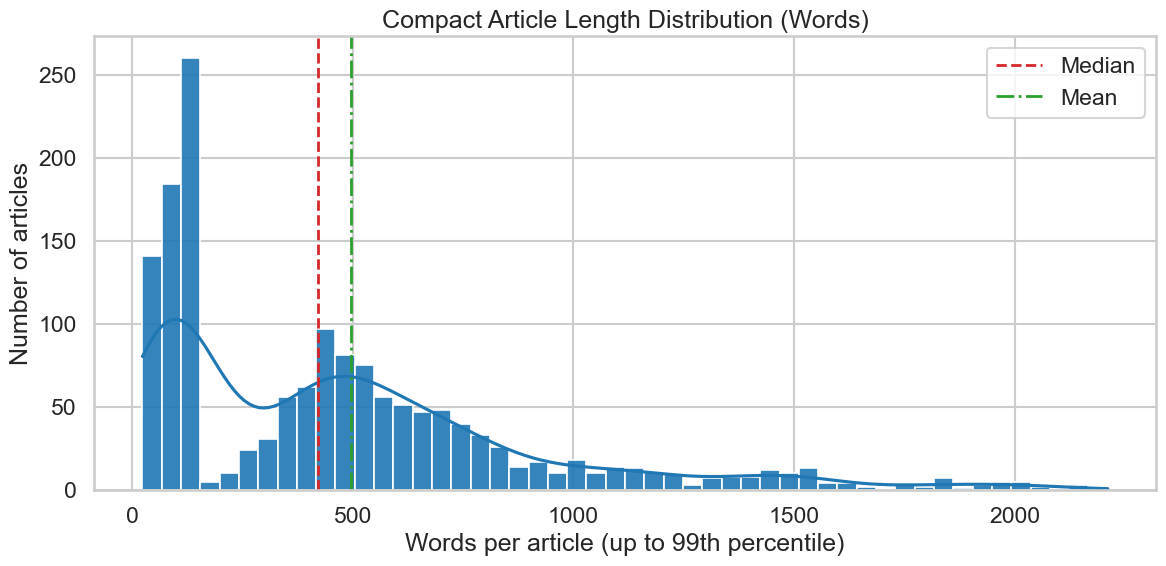

In [28]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Compact Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# Inspect 20 shortest articles by word count
df_inspect = eda_df if "eda_df" in globals() else df_clean.copy()

if "article_length_words" not in df_inspect.columns:
    df_inspect["article_length_words"] = df_inspect["Text"].astype("string").str.split().str.len()

# ensure source column exists (most data is from SOURCE_NAME == "Compact")
if "source" not in df_inspect.columns:
    df_inspect["source"] = SOURCE_NAME if "SOURCE_NAME" in globals() else "Compact"

# build result (Title, text, source, word_count) sorted ascending
shortest = (
    df_inspect.sort_values("article_length_words", ascending=True)
    .loc[:, ["Title", "Text", "source", "article_length_words"]]
    .head(20)
    .rename(columns={"Text": "text", "article_length_words": "word_count"})
)

# allow longer text columns to be displayed
pd.options.display.max_colwidth = 1000

display(shortest)

,Title,text,source,word_count
632,Macron am Boden: Live beim Aufstand!,Frankreich im Ausnahmezustand – COMPACT ist live vor Ort dabei! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,23
594,Albaner (18) sticht auf Lehrerin ein! NOT-OP!,Amoklauf in Essener Schule. SEK muss schießen. Dr. Stephanie Elsässer klärt auf! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,25
646,MOSSAD und 9/11,Heute vor 24 Jahren: Israelische Geheimdienstler wurden nach den Anschlägen des 11. September 2001 vom FBI festgenommen und zwei Monate eingesperrt. Waren sie in das Terrorkomplott verwickelt?,Compact,27
464,„Remigration!“: Söder-Interview wird abgebrochen!,Aufregung am Bundestag! Das Sommer-Interview der ARD mit CSU-Chef Söder muss abgebrochen werden. Wir sind vor Ort! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,30
1187,Halle (Saale): Antifa brüllt gegen Buchmesse,"Wirbel um die «Seitenwechsel»-Buchmesse in Halle (Saale). Sehen Sie hier brüllende Antifas, spannende Interviews und Impressionen von unserem Messestand! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,32
1388,AfD-Jugend: COMPACT beim Kampf um Gießen!,"Ausnahmezustand in Gießen: Tausende Antifa wollen den Gründungskongress der AfD-Jugend stürmen! Blockaden, Wasserwerfer, Angriffe auf Polizisten und Teilnehmer. COMPACT mittendrin! COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,33
1901,Vor Ort: Orban geht gegen Hammerbande vor!,"In Budapest strebt der Prozess gegen Hammerbanden-„Maja“ seinem Höhepunkt entgegen. Unser Korrespondent Sebastian Schmidtke ist dabei und dokumentiert, wie deutsche Politiker vor Ort Stimmung machen. Die Reportage sehen Sie in dem Video oben.",Compact,33
1575,Gefahr Migration: Ex-Islamist packt aus!,Irfan Peci war Propaganda-Chef der deutschen al-Qaida! Inzwischen hat er zum christlichen Glauben gefunden und warnt vor den schrecklichen Folgen der Massenmigration. Was steht Deutschland bevor? Unsere heutige Shop-Empfehlung: „COMPACT-Spezial 45: Mädchen. Messer. Morde“,Compact,34
1656,Rückblick: Unsere größten TV-Highlights!,Nur noch wenige Stunden… – 2025 war ein spektakuläres Jahr mit vielen Höhen und Tiefen. In unserem COMPACT-Rückblick sehen Sie die wichtigsten Ereignisse in einer kurzweiligen Zusammenfassung. Wir wünschen einen frohen Jahreswechsel und ein gesundes Neues!,Compact,36
1692,Spreewald: Wird SIE die erste AfD-Landrätin?,Widerstand im Gurkenland: Der Kreis Oberspreewald-Lausitz gilt als AfD-Hochburg. In wenigen Tagen wird hier ein neuer Landrat gewählt. Die blaue Kandidatin hat gute Chancen. Paul Klemm hat sie mit der Kamera begleitet. Unsere heutige Produktempfehlung: Silbermedaille Höcke-Taler,Compact,37


--> This indicates two types of documents in the corpus: News briefs / ticker posts and Normal articles

NameError: name 'daily_counts' is not defined

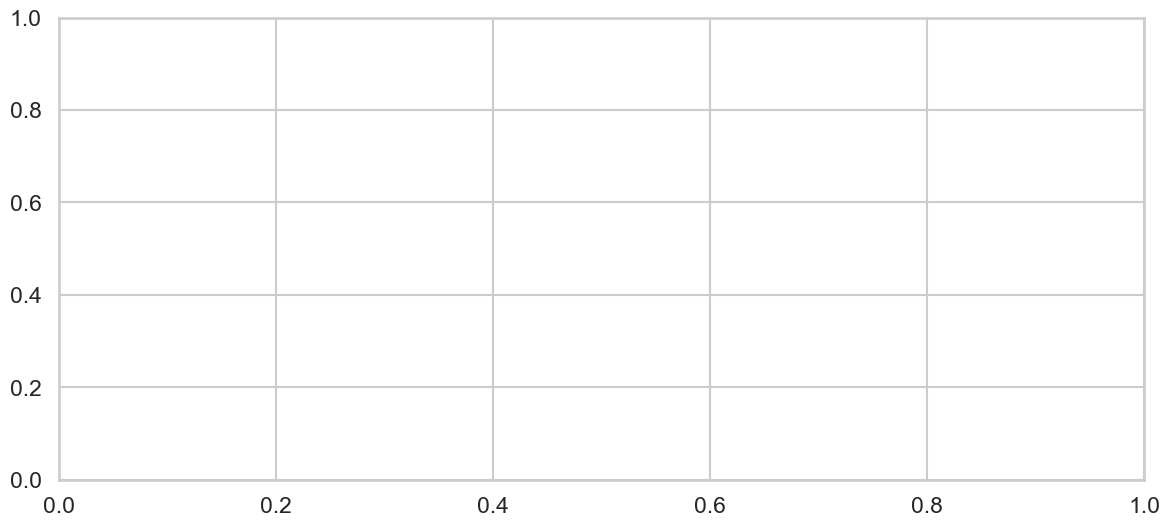

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("Compact Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

In [9]:
compact_clean = df_clean.copy()

if "Inhalt" in compact_clean.columns:
    compact_clean = compact_clean.rename(columns={"Inhalt": "Text"})

compact_clean["source"] = "Compact"
compact_clean = compact_clean[["Date", "Title", "Text", "source"]].copy()
compact_clean.to_csv("compact_clean.csv", index=False, encoding="utf-8")

## BERTopic

In [40]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [41]:
from BERTopic.bertopic_config import BERTopicConfig, title_config
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [42]:
df_clean[["Inhalt", "Title", "URL"]].head()


,Inhalt,URL
0,Der zweite und letzte Verhandlungstag im COMPACT-Verbotsverfahren ist abgeschlossen. Das Urteil wird am 24.06. bekannt gegeben. Wie verlief es heute vor Gericht? Wessen Chancen stehen am Ende besser? Kann sich die Regierung durchsetzen oder obsiegt die Pressefreiheit? Eine Analyse und die Prognose zu diesem historischen Verfahren liefern Ihnen das Ehepaar Elsässer und Paul Klemm.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,https://www.compact-online.de/compact-gegen-regierung-so-war-der-2-tag/
1,"Als Nancy Faeser eskalierte. Die denkwürdigsten Szenen des 16. Juli 2024, also plötzlich die Formate von COMPACT verboten wurden.\n\nUnser Cutter hat anlässlich des laufenden Verbotsverfahren die bemerkenswertesten Szenen zusammengeschnitten.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/compact-verbot-2024-der-film/
2,"Ein neuer Fund in den peruanischen Anden eröffnet einen neuen Blick auf die Kultur der Inka: Sie waren nicht nur große Baumeister, sondern erforschten auch astronomische und spirituelle Geheimnisse – unter Einsatz psychoaktiver Substanzen. Mehr über die Frühzeit der Menschheit und historische Ungereimtheiten lesen Sie „Geheime Geschichte – Von den Pharaonen bis zur Kabale im Vatikan“ – unserer neuen Geschichtsausgabe. Hier mehr erfahren. \n\nHoch oben in den schroffen Felsen der peruanischen Anden, auf fast 3.000 Metern Höhe, haben Archäologen eine Entdeckung gemacht, die nicht nur die Fachwelt elektrisiert: Ein geheimer, unterirdischer Raum, der vermutlich seit Jahrtausenden unberührt war, gibt nun Einblicke in die mysteriösen Rituale der Inka – jenes alten lateinamerikanischen Volkes, das um die Hauptstadt Cusco im heutigen Peru lebte und ab 1438 viele Gebiete eroberte, insbesondere im Anden-Gebirge. Das Reich der Inka gilt als das größte seiner Zeit und umfasste schätzungsweise ...",https://www.compact-online.de/drogen-und-rituale-mysterioese-inka-staette-entdeckt/
3,"Das Durchgreifen des US-Präsidenten gegen das Treiben illegaler Einwanderer in Los Angeles treibt etablierte Medien um. Wir zeigen auf, wie Trump tickt und was wir von ihm noch zu erwarten haben. Sichern Sie sich am besten gleich unsere Sonderausgabe „Trump. Sein Leben. Seine Politik. Sein großes Comeback.“ Hier mehr erfahren.\n\nDie Straßen von Los Angeles stehen in Flammen – brennende Polizeiwagen, fliegende Steine und Proteste. Die Szenen lassen an einen Bürgerkrieg denken. Auslöser der Krawalle waren Razzien der Einwanderungsbehörden gegen illegale Migranten. Präsident Donald Trump reagiert entschlossen und schickt 2.000 Soldaten der Nationalgarde sowie 700 Marines, um die Gewalt in den Griff zu bekommen – ein Schritt, der weltweit für Schlagzeilen sorgt. Die internationale Presse ist in Aufruhr, die Meinungen aus der Straße sind gespalten.\n\nTrumps Entscheidung, Kaliforniens Gouverneur Gavin Newsom und die Bürgermeisterin von Los Angeles, Karen Bass, beide Demokraten, zu über...",https://www.compact-online.de/trumps-einsatz-in-los-angeles-ein-medientrauma/
4,"Essay von Rolf Hochhut. Deutschland hat seinen großen Kanzler vergessen – vor allem von seiner klugen Ausgleichspolitik mit Russland wollen die heutigen NATO-Vasallen nichts mehr wissen. _ von Rolf Hochhuth Bismarcks geheimer Rückversicherungsvertrag mit Russland sah vor: Berlin und Petersburg bleiben «wohlwollend neutral», wird eines der beiden Länder «in Krieg mit einer Großmacht verwickelt». Der Kanzler sagte befriedigt: «So ist ein Krieg in Europa überhaupt nicht mehr möglich, es sei denn wegen irgendeiner Schweinerei auf\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort v

In [43]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Inhalt",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="Compact",
)

# 2) BERTopic on titles only
result_title = run_bertopic_pipeline(
    df=df_clean,
    text_col="Title",
    config=title_config(),
    id_col="URL",
    source_name="Compact",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-06 16:46:40,779 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-03-06 16:46:49,574 - BERTopic - Embedding - Completed ✓
2026-03-06 16:46:49,575 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-06 16:46:53,481 - BERTopic - Dimensionality - Completed ✓
2026-03-06 16:46:53,482 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-06 16:46:53,514 - BERTopic - Cluster - Completed ✓
2026-03-06 16:46:53,518 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-06 16:46:54,116 - BERTopic - Representation - Completed ✓


In [44]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,470,-1_kirk_charlie_musk_antifa,"[kirk, charlie, musk, antifa, charlie kirk, spezial, washington, polizei, cia, gewalt]","[Jetzt greift die Trump-Regierung gegen linke Aufwiegler durch: Mehreren ausländische Staatsbürgern, darunter einem ZDF-Journalisten, wurde das Visum für die USA entzogen, nachdem sich die Betroffenen verhöhnend über die Ermordung des amerikanischen Konservativen Charlie Kirk geäußert hatten. Während Hetzer in die Schranken gewiesen werden, erhielt Kirk derweil postum eine der höchsten Auszeichnungen des Landes. Es wird immer deutlicher: Das politische Klima ändert sich. Besorgen Sie sich deshalb jetzt unbedingt unsere Spezial-Ausgabe über Trump, um diesen Wandel nachvollziehen zu können. Hier mehr erfahren. „Wenn Faschisten sterben, jammern Demokraten nicht“, polterte der ZDF-Journalist Mario Sixtus nach der Ermordung von Charlie Kirk unverhohlen im sozialen Netzwerk „Bluesky“. Und dachte offenbar, dass es für ihn, wie bei so vielen ähnlichen Beiträgen, keine Konsequenzen gäbe. Ein Irrtum: Wie von der US-Regierung angekündigt, werden derzeit die zahlreichen hämischen Beiträge, mit..."
1,0,278,0_bsw_höcke_parteien_blauen,"[bsw, höcke, parteien, blauen, altparteien, wähler, umfrage, brandmauer, bundestag, kanzlermedaille]","[Das ist ein Paukenschlag: Nach einer neuen Umfrage wäre die AfD in Brandenburg bei der nächsten Landtagswahl klar stärkste Partei. Und hätte sogar mehr Wähler, als die Regierungskoalition von SPD und BSW zusammen. Die Partei von Alice Weidel, Christoph Berndt und natürlich Björn Höcke wird immer stärker. Bekennen auch Sie sich jetzt: Mit dem Höcke-Taler aus feinstem Silber, exklusiv bei uns im Sortiment. Hier mehr erfahren. Würde diesen Sonntag in Brandenburg gewählt, käme die AfD auf starke 32 % und könnte ihre Zustimmungswerte weiter steigern – das ergab eine aktuelle Umfrage von infratest dimap im Auftrag des rbb. Ganz anders sieht es dagegen für die Regierungskoalition von Ministerpräsident Woidke aus: Die SPD stürzt ab, verliert fünf Prozent, nur noch 23 % würden die ehemalige Arbeiterpartei wählen. Und auch das BSW lässt Federn, verliert ein Viertel der Wähler und käme lediglich noch auf 9 %. Zwar kann die Linkspartei davon profitieren (9 %), doch insgesamt zeigt sich: Die A..."
2,1,259,1_geheime_wisnewski_jan_hitler,"[geheime, wisnewski, jan, hitler, stadt, wikimedia, commons, wikimedia commons, kultur, 1945]","[Die im Verborgenen wirkenden Freimaurer arbeiten angeblich nur an sich selbst. Zwei einschneidende Ereignisse der Weltgeschichte tragen jedoch eindeutig ihre Handschrift. Die Wahrheit über Freimaurer, Illuminaten, B’nai B’rith, Skull & Bones und andere Hintergrundmächte lesen Sie in dem brandneuen Enthüllungswerk «Geheimgesellschaften und ihre Macht im 21. Jahrhundert» von Verschwörungs-Legende Jan van Helsing. So entlarvend, dass der Vorgängerband von der politisierten Justiz beschlagnahmt wurde! Hier mehr erfahren. _ von Guido Grandt Die Freimaurerei geht auf die mittelalterlichen Dombauhütten mit ihren Gildenbruderschaften zurück. Diese freien Maurer (Freemasons), Steinmetze, Bildhauer und Architekten hüteten gegenüber Außenstehenden sorgsam die Geheimnisse ihrer Kunst, genauso mathematisches und geometrisches Wissen. Untereinander gaben sie sich durch bestimmte Zeichen, Worte oder Handgriffe zu erkennen. Später öffneten sich ihre Verbände auch anderen Berufsständen – womit die..."
3,2,239,2_nato_moskau_wladimir_krieg gegen,"[nato, moskau, wladimir, krieg gegen, druschba, spezial, patriot, silbermedaille, für frieden, polen]","[Nach der polnischen Drohnenpleite geht es hektisch weiter: Estland behauptet, russische Kampfflugzeuge seien in seinen Luftraum eingedrungen. Moskau dementiert. Unsere neue Spezialausgabe „Krieg gegen Russland“ zeigt, wie aus solchen Lügengeschichten schnell ein Krieg entstehen kann. Hier bestellen. Die „Tagesschau“ meldet heute: „Russland hatte zum wiederholten Mal den Luftraum eines NATO

In [45]:
doc_info = result["doc_info"]
doc_info.head()

,original_index,document_id,source_name,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,0,https://www.compact-online.de/compact-gegen-regierung-so-war-der-2-tag/,Compact,Der zweite und letzte Verhandlungstag im COMPACT-Verbotsverfahren ist abgeschlossen. Das Urteil wird am 24.06. bekannt gegeben. Wie verlief es heute vor Gericht? Wessen Chancen stehen am Ende besser? Kann sich die Regierung durchsetzen oder obsiegt die Pressefreiheit? Eine Analyse und die Prognose zu diesem historischen Verfahren liefern Ihnen das Ehepaar Elsässer und Paul Klemm. COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,4,4_antifa_000 seiten_seiten_diktatur,"[antifa, 000 seiten, seiten, diktatur, 99, gericht, paket, rechts, urteil, julia]","[Weil sie angeblich geplant gehabt hätten, den damaligen Bundesgesundheitsminister Karl Lauterbach zu entführen, ging der Generalbundesanwalt im Frühjahr 2022 gegen sogenannte „Reichsbürger“ vor. Das Verfahren mündete in einen großen Prozess, es gab Verurteilungen. Doch das reicht der Justiz nicht: Drei Jahre später geht die Polizei in Sachsen mit neuen Razzien gegen angebliche Unterstützer vor. Einmal mehr drängt sich der Verdacht auf, dass im „Kampf gegen Rechts“ die Verhältnismäßigkeit fehlt. Lesen Sie in unserem Aufklärungspaket „1.000 Seiten BRD-Diktatur“, wie schlimm es wirklich um die Meinungsfreiheit steht, nicht nur in Deutschland. 11 entlarvende COMPACT-Ausgaben für nur 14,99 statt 79,75 Euro. Hier mehr erfahren. Im April 2022 ging die Staatsmacht mit einem Großaufgebot gegen eine Gruppierung vor, die sich „Vereinte Patrioten“ genannt haben soll und deren Akteure teilweise im Corona-Widerstand aktiv geworden sind. Vorgeworfen wurde mehreren Personen, einen Umsturz mit Waf...",antifa - 000 seiten - seiten - diktatur - 99 - gericht - paket - rechts - urteil - julia,1.000000,False
1,1,https://www.compact-online.de/compact-verbot-2024-der-film/,Compact,"Als Nancy Faeser eskalierte. Die denkwürdigsten Szenen des 16. Juli 2024, also plötzlich die Formate von COMPACT verboten wurden. Unser Cutter hat anlässlich des laufenden Verbotsverfahren die bemerkenswertesten Szenen zusammengeschnitten. COMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",8,8_bestellung_veranstaltung_cover_okkulte reich,"[bestellung, veranstaltung, cover, okkulte reich, 15 jahre, björn, okkulte, mut, schicksalstage deutschen, schicksalstage]","[COMPACT beschenkt seine Kunden: Sie erhalten GRATIS unsere Geschichtsausgabe „Das okkulte Reich“ (im Wert von 9,90 Euro) – für jede Bestellung, die in unserem Online-Shop eingeht. Aber nur noch bis Dienstag, 2. Dezember 2025, 24 Uhr! Dieses Angebot gilt für alle Inlandsbestellungen – und nur, so lange der Vorrat reicht. Weihnachten steht vor der Tür – und wir haben jetzt eine Reihe neuer Produkte im Shop, die Jung und Alt erfreuen. Stöbern Sie in unseren Angeboten und finden Sie das passende Geschenk – für Ihre Liebsten oder für sich. Edle Silber-Medaillen, politisch unkorrekte Bücher, hochinformative Sonderausgaben und echte Schnäppchen. Sie erhalten auch ein Geschenk von uns! Denn: Für jede Bestellung, die in unserem Online-Shop eingeht, erhalten Sie COMPACT-Geschichte „Das okkulte Reich – Nazis und Esoterik“ kostenlos dazu! In COMPACT-Geschichte „Das okkulte Reich“ dringen wir in absolute Tabuzonen vor: Lesen Sie alles über die sagenumwobene Thule-Gesellschaft, die mysteriöse W...",bestellung - veranstaltung - cover - okkulte reich - 15 jahre - björn - okkulte - mut - schicksalstage deutschen - schicksalstage,0.642755,False
2,2,https://www.compact-online.de/drogen-und-rituale-mysterioese-inka-staette-entdeckt/,Compact,"Ein neuer Fund in den peruanischen Anden eröffnet einen neuen Blick auf die Kultur der Inka: Sie waren nicht nur große Baumeister, sondern erforschten auch astronomische und spirituelle Geheimnisse – unte

In [46]:
compact_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

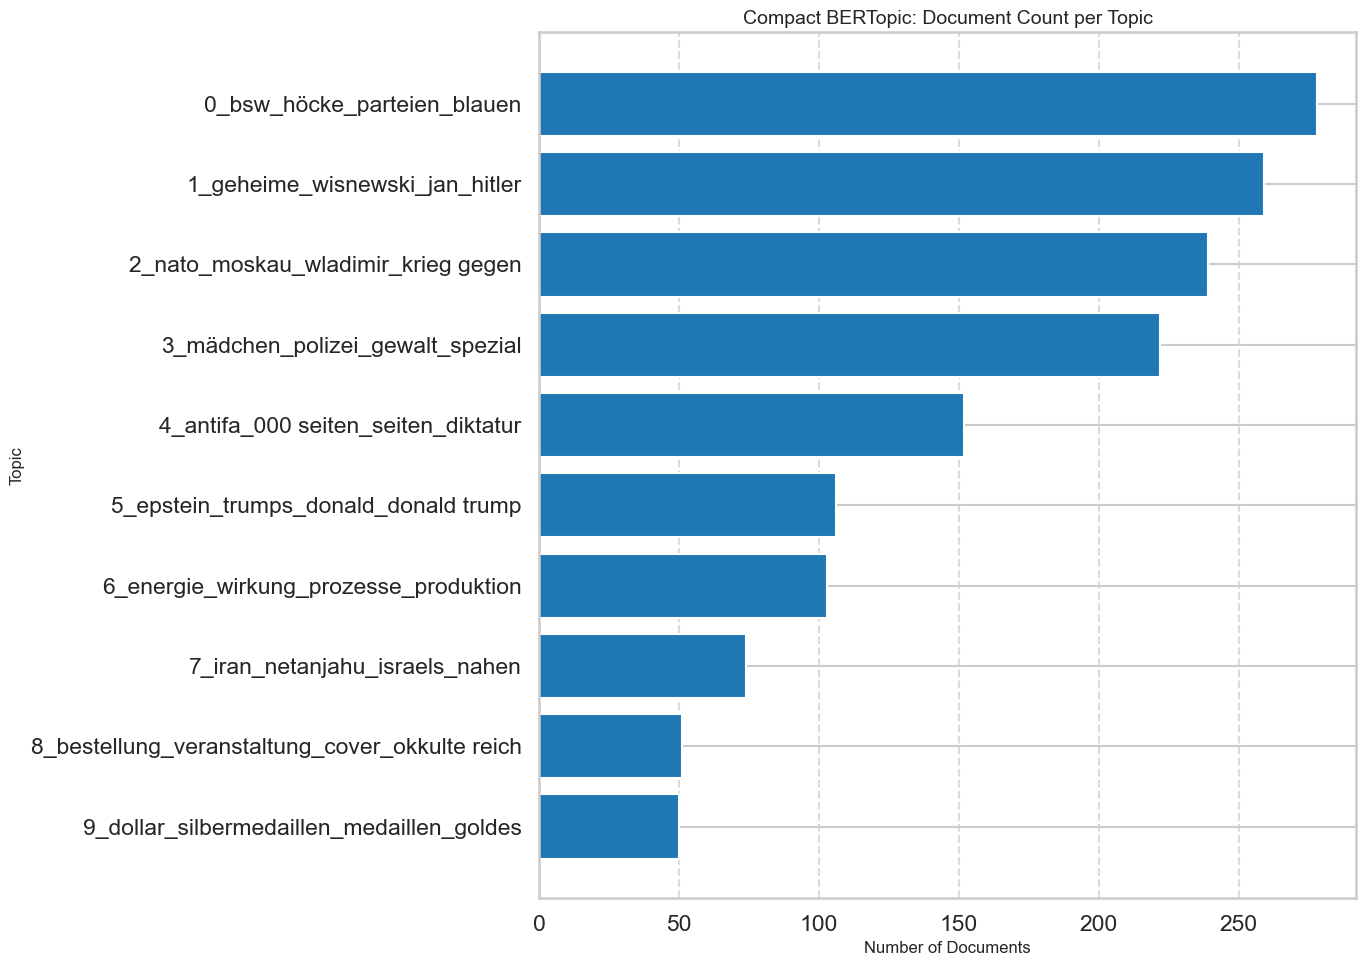

In [47]:
fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('Compact BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6it [00:00, 14.62it/s]


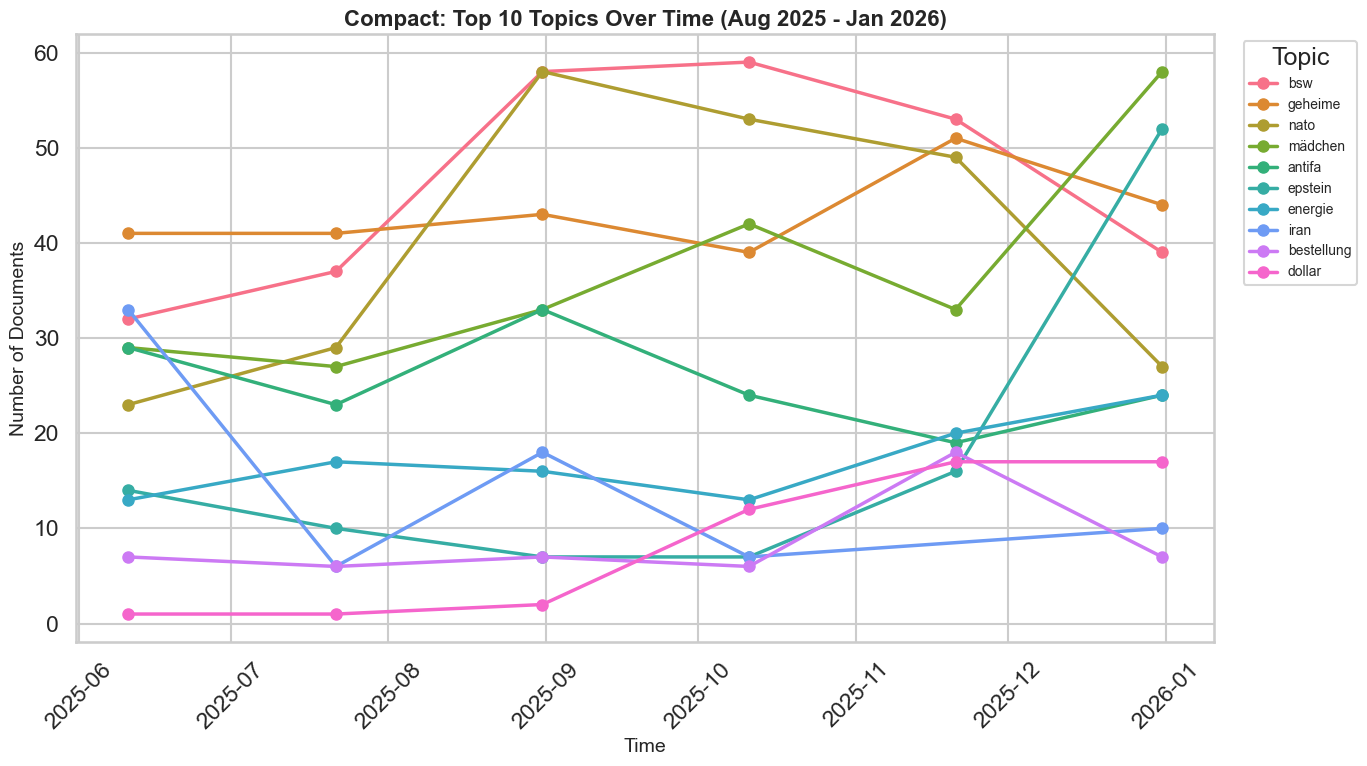

In [48]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["Date"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('Compact: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
# Final BERTopic comparison table: all topics + representative words
from IPython.display import display

topics_comparison_df = topic_info[["Topic", "Name", "Count"]].copy()

def _representative_words_for_topic(topic_id: int) -> str:
    terms = result["topic_model"].get_topic(int(topic_id)) or []
    return ", ".join(word for word, _ in terms)

topics_comparison_df["Representative_Words"] = topics_comparison_df["Topic"].apply(_representative_words_for_topic)
topics_comparison_df = topics_comparison_df.sort_values("Topic").reset_index(drop=True)

with pd.option_context("display.max_colwidth", None, "display.width", 220):
    display(topics_comparison_df)


,Topic,Name,Count,Representative_Words
0,-1,-1_kirk_charlie_musk_antifa,470,"kirk, charlie, musk, antifa, charlie kirk, spezial, washington, polizei, cia, gewalt"
1,0,0_bsw_höcke_parteien_blauen,278,"bsw, höcke, parteien, blauen, altparteien, wähler, umfrage, brandmauer, bundestag, kanzlermedaille"
2,1,1_geheime_wisnewski_jan_hitler,259,"geheime, wisnewski, jan, hitler, stadt, wikimedia, commons, wikimedia commons, kultur, 1945"
3,2,2_nato_moskau_wladimir_krieg gegen,239,"nato, moskau, wladimir, krieg gegen, druschba, spezial, patriot, silbermedaille, für frieden, polen"
4,3,3_mädchen_polizei_gewalt_spezial,222,"mädchen, polizei, gewalt, spezial, frauen, lars, migranten, fälle, behörden, hamburg"
5,4,4_antifa_000 seiten_seiten_diktatur,152,"antifa, 000 seiten, seiten, diktatur, 99, gericht, paket, rechts, urteil, julia"
6,5,5_epstein_trumps_donald_donald trump,106,"epstein, trumps, donald, donald trump, dollar, washington, insel, präsident donald, frauen, mädchen"
7,6,6_energie_wirkung_prozesse_produktion,103,"energie, wirkung, prozesse, produktion, produkte, blut, für diese, senken, hilft, keinerlei"
8,7,7_iran_netanjahu_israels_nahen,74,"iran, netanjahu, israels, nahen, nahen osten, osten, kennedy, ausgabe titelthema, region, trumps"
9,8,8_bestellung_veranstaltung_cover_okkulte reich,51,"bestellung, veranstaltung, cover, okkulte reich, 15 jahre, björn, okkulte, mut, schicksalstage deutschen, schicksalstage"


In [ ]:
# BERTopic v2 run: full text first, then title-only
from BERTopic.bertopic_pipelinev2 import (
    BERTopicV2Config,
    BERTopicV2ConfigTitle,
    run_bertopic_pipeline,
)

result_full_text_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="Inhalt",
    config=BERTopicV2Config(),
    id_col="URL",
    source_name="Compact",
)

result_title_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="Title",
    config=BERTopicV2ConfigTitle(),
    id_col="URL",
    source_name="Compact",
)

print(
    f"v2 full-text docs: {len(result_full_text_v2['docs']):,} | "
    f"v2 title docs: {len(result_title_v2['docs']):,}"
)

